# Modélisation de la fonction de masse des amas
On implémente ici plusieurs versions de la fonction de masse des amas $\frac{dn}{dM}(z)$ ($Mpc^{-3} dex^{-1}$), c'est à dire la densité volumique d'amas de galaxies de masse comprises dans l'intervalle $[M - dM ; M + dM]$ pour un certain redshift z. 

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import math
import pickle
import os
from scipy.optimize import minimize
from scipy.interpolate import interp1d

In [3]:
from halo_and_cluster_MF import *
from useful_functions import *

# Murray, Robotham and Power 
Voir Murray, Robotham, Power 2013 / Murray et al. 2021 / Driver et al. 2022

Les valeurs suivantes et définitions de fonction de masse des amas (CMF) sont tirées de Friver et al. 2022.

## Implémentation

In [4]:
# On prend différents quelques lots de paramètres issus de Driver et al .2021 (on prend ceux issus d'un fit sur plusieurs relevés)
# Les paramètres sont de la forme : (log10_Mmedian_Msun,log10_phimedian,alpha,beta)

# Params GSR (GAMA5 + SDSS5 + REFLEX II) : ce sont les paramètres finalament retenus dans Driver et al. 2021
params_GSR = [14.13,-3.96,-1.68,0.63] # valeurs moyennes 
'''params_GSR_max = [14.13+0.43,-3.96+0.55,-1.68+0.21,0.63+0.25] # Borne max erreurs à 1 sigma
params_GSR_min = [14.13-0.40,-3.96-0.82,-1.68-0.24,0.63-0.11] # Borne min erreurs à 1 sigma'''

bounds_params_GSR = [(14.13-0.40,14.13+0.43),(-3.96-0.82,-3.96+0.55),(-1.68-0.24,-1.68+0.21),(0.63-0.11,0.63+0.25)]

# Params SR (SDSS5 + REFLEX II)
params_SR = [14.44,-4.52,-1.85,0.79] # valeurs moyennes 
'''params_SR_max = [14.44+0.25,-4.52+0.66,-1.85+0.21,0.79+0.23] # Borne max erreurs à 1 sigma
params_SR_min = [14.44-0.38,-4.52-0.58,-1.85-0.18,0.79-0.18] # Borne min erreurs à 1 sigma'''

bounds_params_SR = [(14.44-0.38,14.44+0.25),(-4.52-0.58,-4.52+0.66),(-1.85-0.18,-1.85+0.21),(0.79-0.18,0.79+0.23)]

# Params GR (GAMA5 + REFLEX II)
params_GR = [13.72,-3.44,-1.29,0.55] # valeurs moyennes
'''params_GR_max = [13.72+0.64,-3.44+0.26,-1.29+0.32,0.55+0.26] # Borne max erreurs à 1 sigma
params_GR_min = [13.72-0.43,-3.44-0.93,-1.29-0.41,0.55-0.08] # Borne min erreurs à 1 sigma'''

bounds_params_GR = [(13.72-0.43,13.72+0.64),(-3.44-0.93,-3.44+0.26),(-1.29-0.41,-1.29+0.32),(0.55-0.08,0.55+0.26)]

# Params GS (GAMA5 + SDSS5)
params_GS = [14.35,-4.38,-1.96,0.60] # valeurs moyennes
'''params_GS_max = [14.35+0.36,-4.38+0.93,-1.96+0.37,0.60+0.15] # Borne max erreurs à 1 sigma
params_GS_min = [14.35-0.60,-4.38-0.73,-1.96-0.18,0.60-0.10] # Borne min erreurs à 1 sigma'''

bounds_params_GS = [(14.35-0.60,14.35+0.36),(-4.38-0.73,-4.38+0.93),(-1.96-0.18,-1.96+0.37),(0.60-0.10,0.60+0.15)]

In [5]:
# On paramètres les CMF (Cluster Mass Function)

# IMPORTANT : ces paramètres sont obtenues pour un  z = 0.1

#GSR
CMF_GSR_func = CMF_MRP(params_GSR[0],params_GSR[1],params_GSR[2],params_GSR[3])
'''CMF_GSR_max_func = CMF_MRP(params_GSR_max[0],params_GSR_max[1],params_GSR_max[2],params_GSR_max[3])
CMF_GSR_min_func = CMF_MRP(params_GSR_min[0],params_GSR_min[1],params_GSR_min[2],params_GSR_min[3])'''

#SR
CMF_SR_func = CMF_MRP(params_SR[0],params_SR[1],params_SR[2],params_SR[3])
'''CMF_SR_max_func = CMF_MRP(params_SR_max[0],params_SR_max[1],params_SR_max[2],params_SR_max[3])
CMF_SR_min_func = CMF_MRP(params_SR_min[0],params_SR_min[1],params_SR_min[2],params_SR_min[3])'''

#GR
CMF_GR_func = CMF_MRP(params_GR[0],params_GR[1],params_GR[2],params_GR[3])
'''CMF_GR_max_func = CMF_MRP(params_GR_max[0],params_GR_max[1],params_GR_max[2],params_GR_max[3])
CMF_GR_min_func = CMF_MRP(params_GR_min[0],params_GR_min[1],params_GR_min[2],params_GR_min[3])'''

#GS
CMF_GS_func = CMF_MRP(params_GS[0],params_GS[1],params_GS[2],params_GS[3])
'''CMF_GS_max_func = CMF_MRP(params_GS_max[0],params_GS_max[1],params_GS_max[2],params_GS_max[3])
CMF_GS_min_func = CMF_MRP(params_GS_min[0],params_GS_min[1],params_GS_min[2],params_GS_min[3])'''

'CMF_GS_max_func = CMF_MRP(params_GS_max[0],params_GS_max[1],params_GS_max[2],params_GS_max[3])\nCMF_GS_min_func = CMF_MRP(params_GS_min[0],params_GS_min[1],params_GS_min[2],params_GS_min[3])'

In [6]:
log10_M_Msun = np.linspace(12.7,15.5,1000) # Les fits desquels sont issus les paramètres sont valables pour des masses comprises entre 10^12.7 et 10^15.5 Msun
M_Msun = 10**log10_M_Msun
log10_M_Msun = log10_M_Msun.tolist()

print(log10_M_Msun)
type(log10_M_Msun)

[12.7, 12.702802802802802, 12.705605605605605, 12.708408408408408, 12.71121121121121, 12.714014014014014, 12.716816816816817, 12.71961961961962, 12.722422422422422, 12.725225225225225, 12.728028028028028, 12.730830830830831, 12.733633633633634, 12.736436436436435, 12.739239239239238, 12.74204204204204, 12.744844844844843, 12.747647647647646, 12.75045045045045, 12.753253253253252, 12.756056056056055, 12.758858858858858, 12.76166166166166, 12.764464464464464, 12.767267267267266, 12.77007007007007, 12.772872872872872, 12.775675675675675, 12.778478478478478, 12.78128128128128, 12.784084084084084, 12.786886886886887, 12.78968968968969, 12.792492492492492, 12.795295295295295, 12.798098098098098, 12.800900900900901, 12.803703703703704, 12.806506506506507, 12.809309309309308, 12.81211211211211, 12.814914914914914, 12.817717717717716, 12.82052052052052, 12.823323323323322, 12.826126126126125, 12.828928928928928, 12.83173173173173, 12.834534534534534, 12.837337337337337, 12.84014014014014, 12.84

list

In [7]:
# Propagation des erreurs sur les CMF à l'aide d'une méthode d'optimisation (on pourrait aussi essayer de récupérer les covatiances des paramètres (regarder le arxiv de Driver et al. 2022 ?) et aplliquer la formule de propagation des erreurs)

CMF_test = CMF_MRP_2(13.0) ; CMF_test_opposite = CMF_MRP_2_opposite(13.0)

'''result_CMF_test_min = minimize(fun = CMF_test, x0 = params_GSR, bounds=bounds_params_GSR, method='SLSQP')
result_CMF_test_max = minimize(fun = CMF_test_opposite, x0 = params_GSR, bounds=bounds_params_GSR, method='SLSQP') ; result_CMF_test_max = np.abs(result_CMF_test_max.fun) '''

Borne_min_CMF_GSR = [] ; Borne_max_CMF_GSR = []
Borne_min_CMF_SR = [] ; Borne_max_CMF_SR = []
Borne_min_CMF_GR = [] ; Borne_max_CMF_GR = []
Borne_min_CMF_GS = [] ; Borne_max_CMF_GS = []

for x in log10_M_Msun:
    CMF_current = CMF_MRP_2(x) ; CMF_current_opposite = CMF_MRP_2_opposite(x)

    #GSR
    result_CMF_current_min = minimize(fun = CMF_current, x0 = params_GSR, bounds=bounds_params_GSR, method='COBYLA') ; result_CMF_test_min = result_CMF_current_min.fun
    result_CMF_current_max = minimize(fun = CMF_current_opposite, x0 = params_GSR, bounds=bounds_params_GSR, method='COBYLA') ; result_CMF_test_max = np.abs(result_CMF_current_max.fun) # On retrouve bien le max car la CMF est une fonction positive
    Borne_min_CMF_GSR.append(result_CMF_test_min) ; Borne_max_CMF_GSR.append(result_CMF_test_max)

    #SR
    result_CMF_current_min = minimize(fun = CMF_current, x0 = params_SR, bounds=bounds_params_SR, method='COBYLA') ; result_CMF_test_min = result_CMF_current_min.fun
    result_CMF_current_max = minimize(fun = CMF_current_opposite, x0 = params_SR, bounds=bounds_params_SR, method='COBYLA') ; result_CMF_test_max = np.abs(result_CMF_current_max.fun)
    Borne_min_CMF_SR.append(result_CMF_test_min) ; Borne_max_CMF_SR.append(result_CMF_test_max)

    #GR
    result_CMF_current_min = minimize(fun = CMF_current, x0 = params_GR, bounds=bounds_params_GR, method='COBYLA') ; result_CMF_test_min = result_CMF_current_min.fun
    result_CMF_current_max = minimize(fun = CMF_current_opposite, x0 = params_GR, bounds=bounds_params_GR, method='COBYLA') ; result_CMF_test_max = np.abs(result_CMF_current_max.fun)
    Borne_min_CMF_GR.append(result_CMF_test_min) ; Borne_max_CMF_GR.append(result_CMF_test_max)

    #GS
    result_CMF_current_min = minimize(fun = CMF_current, x0 = params_GS, bounds=bounds_params_GS, method='COBYLA') ; result_CMF_test_min = result_CMF_current_min.fun
    result_CMF_current_max = minimize(fun = CMF_current_opposite, x0 = params_GS, bounds=bounds_params_GS, method='COBYLA') ; result_CMF_test_max = np.abs(result_CMF_current_max.fun)
    Borne_min_CMF_GS.append(result_CMF_test_min) ; Borne_max_CMF_GS.append(result_CMF_test_max)

    

In [8]:
CMF_GSR = CMF_GSR_func(log10_M_Msun)
'''CMF_GSR_max = CMF_GSR_max_func(log10_M_Msun)
CMF_GSR_min = CMF_GSR_min_func(log10_M_Msun)'''

CMF_SR = CMF_SR_func(log10_M_Msun)
'''CMF_SR_max = CMF_SR_max_func(log10_M_Msun)
CMF_SR_min = CMF_SR_min_func(log10_M_Msun)'''

CMF_GR = CMF_GR_func(log10_M_Msun)
'''CMF_GR_max = CMF_GR_max_func(log10_M_Msun)
CMF_GR_min = CMF_GR_min_func(log10_M_Msun)'''

CMF_GS = CMF_GS_func(log10_M_Msun)
'''CMF_GS_max = CMF_GS_max_func(log10_M_Msun)
CMF_GS_min = CMF_GS_min_func(log10_M_Msun)'''

'CMF_GS_max = CMF_GS_max_func(log10_M_Msun)\nCMF_GS_min = CMF_GS_min_func(log10_M_Msun)'

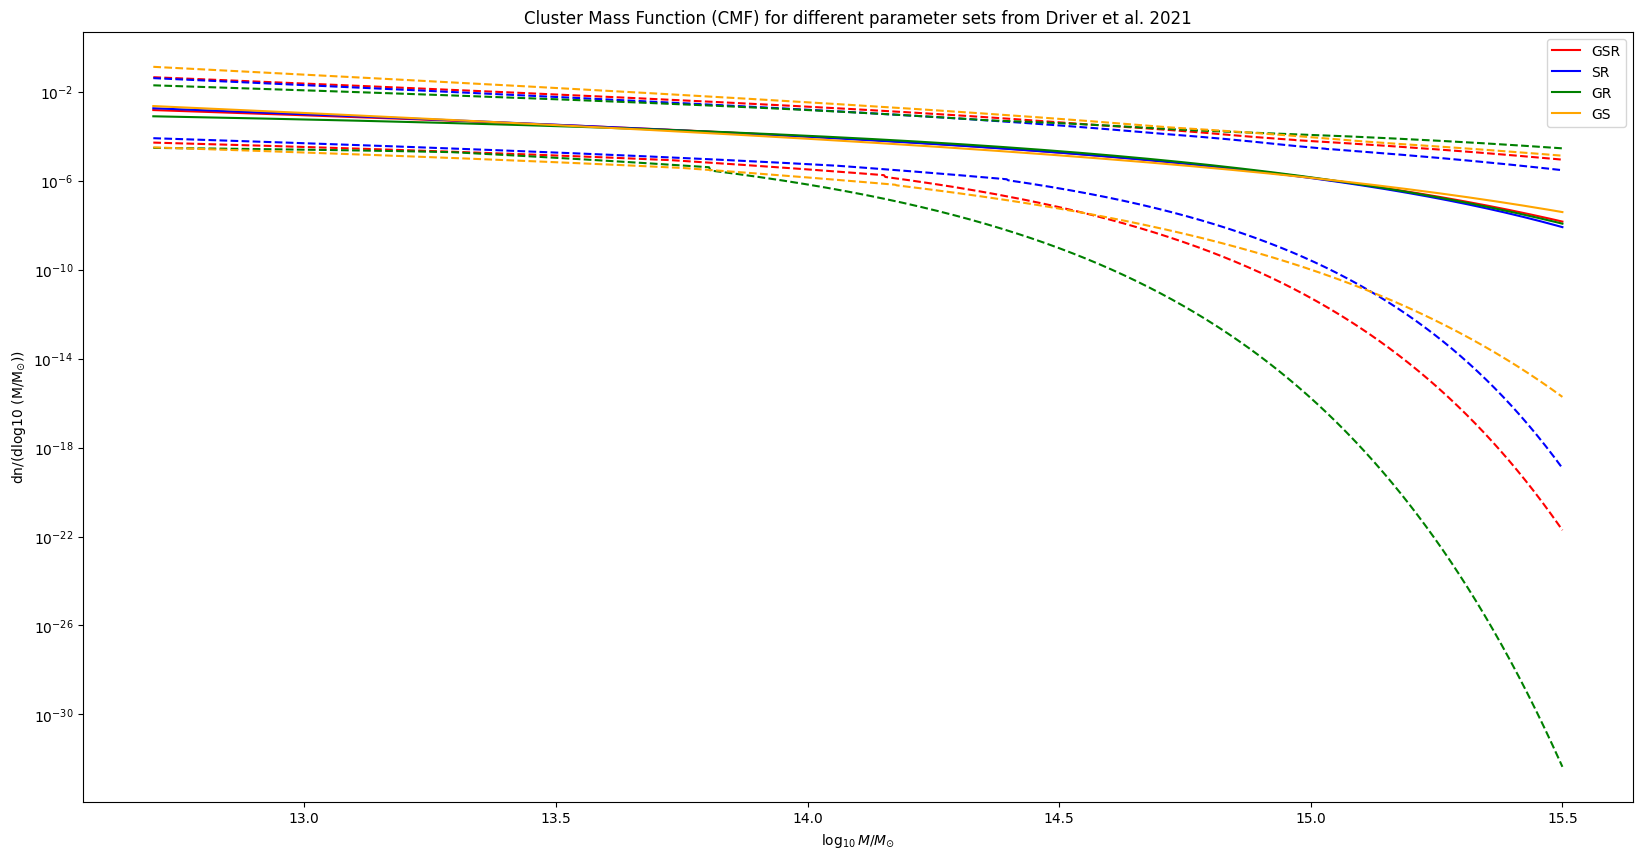

In [9]:
fig = plt.figure(figsize=(20, 10))

plt.plot(log10_M_Msun, CMF_GSR, label='GSR', color='red')
plt.plot(log10_M_Msun, Borne_min_CMF_GSR, color='red',linestyle='dashed')
plt.plot(log10_M_Msun, Borne_max_CMF_GSR, color='red',linestyle='dashed')

plt.plot(log10_M_Msun, CMF_SR, label='SR', color='blue')
plt.plot(log10_M_Msun, Borne_min_CMF_SR, color='blue',linestyle='dashed')
plt.plot(log10_M_Msun, Borne_max_CMF_SR, color='blue',linestyle='dashed')

plt.plot(log10_M_Msun, CMF_GR, label='GR', color='green')
plt.plot(log10_M_Msun, Borne_min_CMF_GR, color='green',linestyle='dashed')
plt.plot(log10_M_Msun, Borne_max_CMF_GR, color='green',linestyle='dashed')

plt.plot(log10_M_Msun, CMF_GS, label='GS', color='orange')
plt.plot(log10_M_Msun, Borne_min_CMF_GS, color='orange',linestyle='dashed')
plt.plot(log10_M_Msun, Borne_max_CMF_GS, color='orange',linestyle='dashed')

plt.xlabel(r'$\log_{10} M / M_{\odot}$')
plt.ylabel(r'dn/(dlog10 (M/M$_{\odot}$))')

plt.yscale('log')

plt.title('Cluster Mass Function (CMF) for different parameter sets from Driver et al. 2021')

plt.legend()


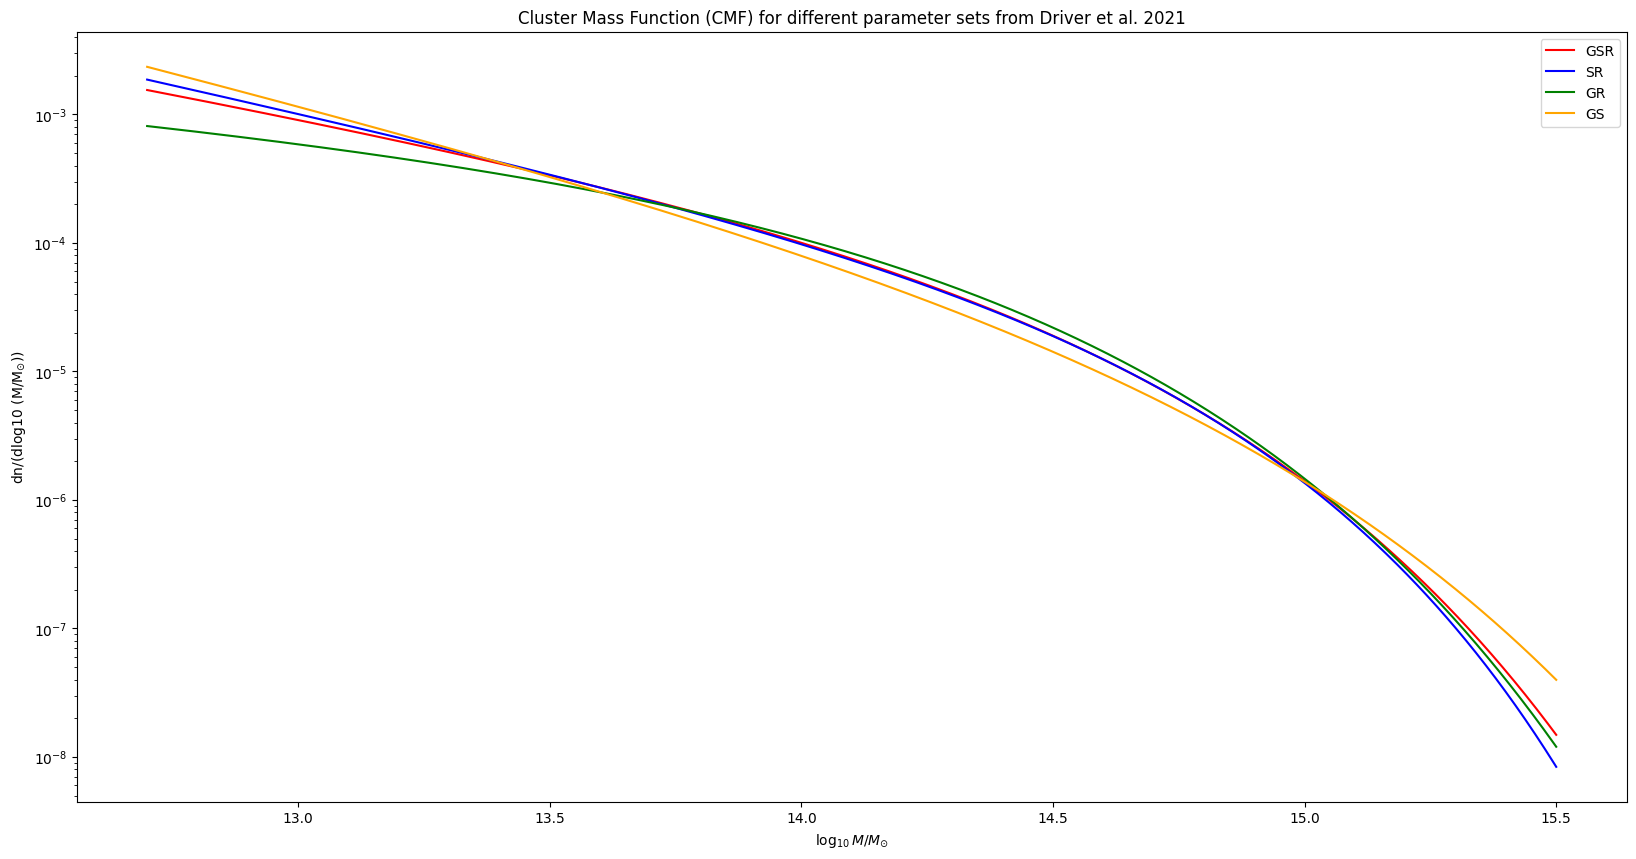

In [10]:
fig = plt.figure(figsize=(20, 10))

plt.plot(log10_M_Msun, CMF_GSR, label='GSR', color='red')


plt.plot(log10_M_Msun, CMF_SR, label='SR', color='blue')

plt.plot(log10_M_Msun, CMF_GR, label='GR', color='green')

plt.plot(log10_M_Msun, CMF_GS, label='GS', color='orange')


plt.xlabel(r'$\log_{10} M / M_{\odot}$')
plt.ylabel(r'dn/(dlog10 (M/M$_{\odot}$))')

plt.yscale('log')

plt.title('Cluster Mass Function (CMF) for different parameter sets from Driver et al. 2021')

plt.legend()

## Calcul nombre d'amas

In [11]:
# ATTENTION : calcul ci desoous PAS VALABLE car la mean density correspond à celle à z = 0.1 → On néglige cependant POUR l'INSTANT l'effet d'évolution de la CMF avec z 

# Nombre théorique d'amas dans le volume couvert par DESI Legacy Imaging Surveys (Wen et Han 2024)
angular_area_deg2 = 24000 # Surface couverte par DESI Legacy Imaging Surveys en degrés carrés
bornes_z = [0,0.65] # Bornes de redshift pour lesquelles on calcule le nombre d'amas (DESI Legacy va jusqu'à z = 1.5)

bornes_log10_M_Msun = [12.7,15.5] # Bornes de masses pour lesquelles la fonction MRP est valable 

volume_DESI_LEGACY = Volume_survey(angular_area_deg2,bornes_z) # Volume en Mpc^3 de la zone couverte par DESI Legacy Imaging Surveys (oon coupe en fait à 0.65 alors que ce relevé va jusqu'à 1.5, et on utilise la distance de diamètre angualaire pour la profondeur)

# GSR / DESI

mean_density_GSR = CMF_to_mean_density(CMF_GSR_func,bornes_log10_M_Msun)
N_GSR_DESI = mean_density_GSR * volume_DESI_LEGACY # Ce serait bien aussi de prendre en compte les erreurs pour avoir une fourchette de valeurs

print('N_GSR_DESI = ',round(N_GSR_DESI/1e6,3),'* 1e6 amas')

# SR / DESI

mean_density_SR = CMF_to_mean_density(CMF_SR_func,bornes_log10_M_Msun)
N_SR_DESI = mean_density_SR * volume_DESI_LEGACY 

print('N_SR_DESI = ',round(N_SR_DESI/1e6,3),'* 1e6 amas')

# GR / DESI

mean_density_GR = CMF_to_mean_density(CMF_GR_func,bornes_log10_M_Msun)
N_GR_DESI = mean_density_GR * volume_DESI_LEGACY

print('N_GR_DESI = ',round(N_GR_DESI/1e6,3),'* 1e6 amas')

# GS / DESI

mean_density_GS = CMF_to_mean_density(CMF_GS_func,bornes_log10_M_Msun)
N_GS_DESI = mean_density_GS * volume_DESI_LEGACY

print('N_GS_DESI = ',round(N_GS_DESI/1e6,3),'* 1e6 amas')



N_GSR_DESI =  6.058 * 1e6 amas
N_SR_DESI =  6.644 * 1e6 amas
N_GR_DESI =  4.296 * 1e6 amas
N_GS_DESI =  7.332 * 1e6 amas


# Comparaison avec les catalogues

## DESI Legacy Imaging surveys

In [12]:
path_DESI = '../SCUSS_DESI/DESI_Legacy_Wen_2024.fit'

table_DESI = fits_to_dataframe(path_DESI)

In [13]:
table_DESI

,_RAJ2000,_DEJ2000,ID,n_Name,Name,RAJ2000,DEJ2000,zCl,f_zCl,zmag,...,logMs,r500,lam500,M500,Ngal,Gamma,e_Gamma,imag_,Cat,recno
0,0.00046,-37.47628,1,,J000000.1-372835,0.00046,-37.47628,0.1364,0,15.377,...,11.49,0.766,25.79,1.17,14,0.0,0.0,1,WHY18,1
1,0.00135,-56.58835,2,WH-,J000000.3-563518,0.00135,-56.58835,0.1957,0,15.712,...,11.70,0.625,23.24,1.06,7,0.0,0.0,1,,2
2,0.00172,-39.32369,3,,J000000.4-391925,0.00172,-39.32369,0.3580,0,17.713,...,11.41,0.526,15.90,0.73,7,0.0,0.0,1,Y21,3
3,0.00201,2.31980,4,,J000000.5+021911,0.00201,2.31980,0.4282,1,18.043,...,11.55,0.612,23.40,1.07,13,0.0,0.0,1,redMaPPer,4
4,0.00260,-59.01297,5,WH-,J000000.6-590047,0.00260,-59.01297,0.1380,0,14.993,...,11.69,0.606,15.71,0.73,7,0.0,0.0,1,,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1581174,359.99667,4.99211,1581175,WH-,J235959.2+045932,359.99667,4.99211,0.5948,0,19.184,...,11.37,0.420,10.99,0.51,6,0.0,0.0,2,,1581175
1581175,359.99680,21.78514,1581176,,J235959.2+214707,359.99680,21.78514,0.4050,1,17.259,...,11.78,0.658,31.73,1.43,9,0.0,0.0,2,WHL,1581176
1581176,359.99817,10.04951,1581177,,J235959.6+100258,359.99817,10.04951,0.7919,0,18.904,...,11.88,0.621,33.23,1.50,8,0.0,0.0,2,CFSFDP,1581177
1581177,359.99847,-6.34469,1581178,WH-,J235959.6-062041,359.99847,-6.34469,1.0333,0,20.952,...,11.18,0.439,13.12,0.61,6,0.0,0.0,2,,1581178


In [14]:
table_DESI.columns

Index(['_RAJ2000', '_DEJ2000', 'ID', 'n_Name', 'Name', 'RAJ2000', 'DEJ2000',
       'zCl', 'f_zCl', 'zmag', 'W1mag', 'logMs', 'r500', 'lam500', 'M500',
       'Ngal', 'Gamma', 'e_Gamma', 'imag_', 'Cat', 'recno'],
      dtype='object')

In [15]:
# Nombre d'amas compris entre les bornes de z utilisés pour le calcul du nombre d'amas à partir de la CMF théorique

N_amas_DESI = len(table_DESI[(table_DESI['zCl'] >= bornes_z[0]) & (table_DESI['zCl'] <= bornes_z[1])])
print('N_amas_DESI = ',N_amas_DESI)

N_amas_DESI =  821225


In [16]:
# A FAIRE → DISTRIBUTION AMAS LUMINOSITE + COULEUR REDSHIFT ...

In [17]:
type(table_DESI['M500'])

pandas.core.series.Series

In [18]:
M500_DESI = np.log10(np.array(table_DESI['M500'])*1e14)
M500_DESI = M500_DESI[(M500_DESI > 12.7) & (M500_DESI < 15.5)] # On ne garde que les amas compris entre les bornes de masses utilisées pour le calcul de la CMF (pour DESI LEgacy, on conserve tout)


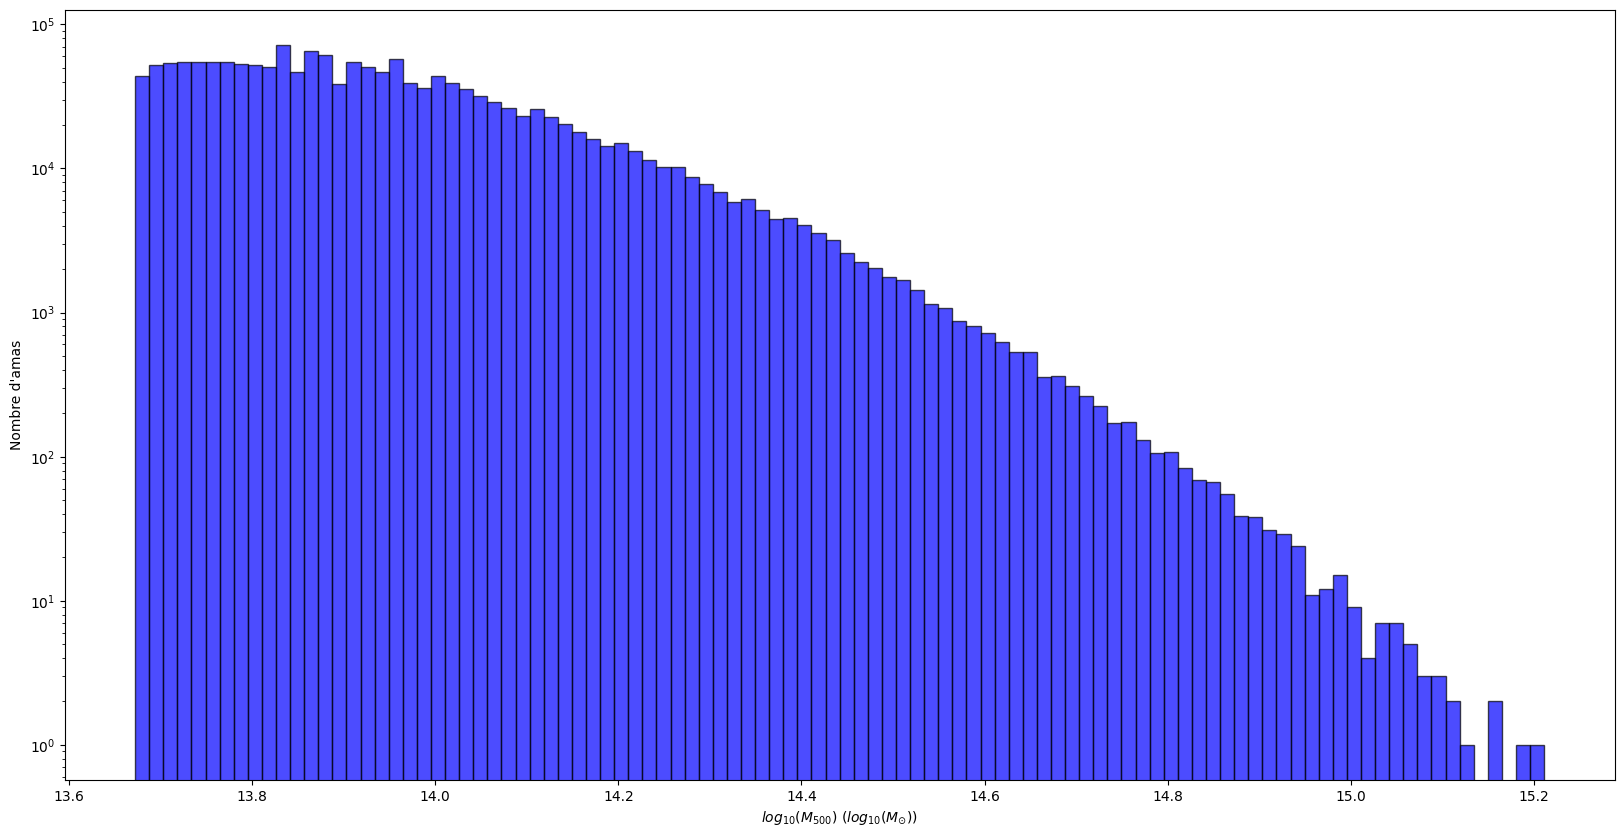

In [19]:
plt.figure(figsize=(20, 10))
plt.hist(M500_DESI, bins=100, color='blue', edgecolor='black', alpha=0.7)
plt.xlabel(r'$log_{10}(M_{500})$ ($log_{10}(M_{\odot})$)')
plt.ylabel('Nombre d\'amas')
plt.yscale('log')

In [20]:
counts, bin_edges = np.histogram(M500_DESI, bins=100)
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:]) # Calculate bin centers
cloud_of_points = list(zip(bin_centers, counts)) # Pair counts with bin centers
# cloud_of_points is now a list of (mass, count) pair

n_DESI_Legacy = counts/volume_DESI_LEGACY # On considère que les amas sont uniformément répartis dans le volume de DESI Legacy : on obtient ainsi une estimation de la densité voulumique par bin de masse avec une simple division

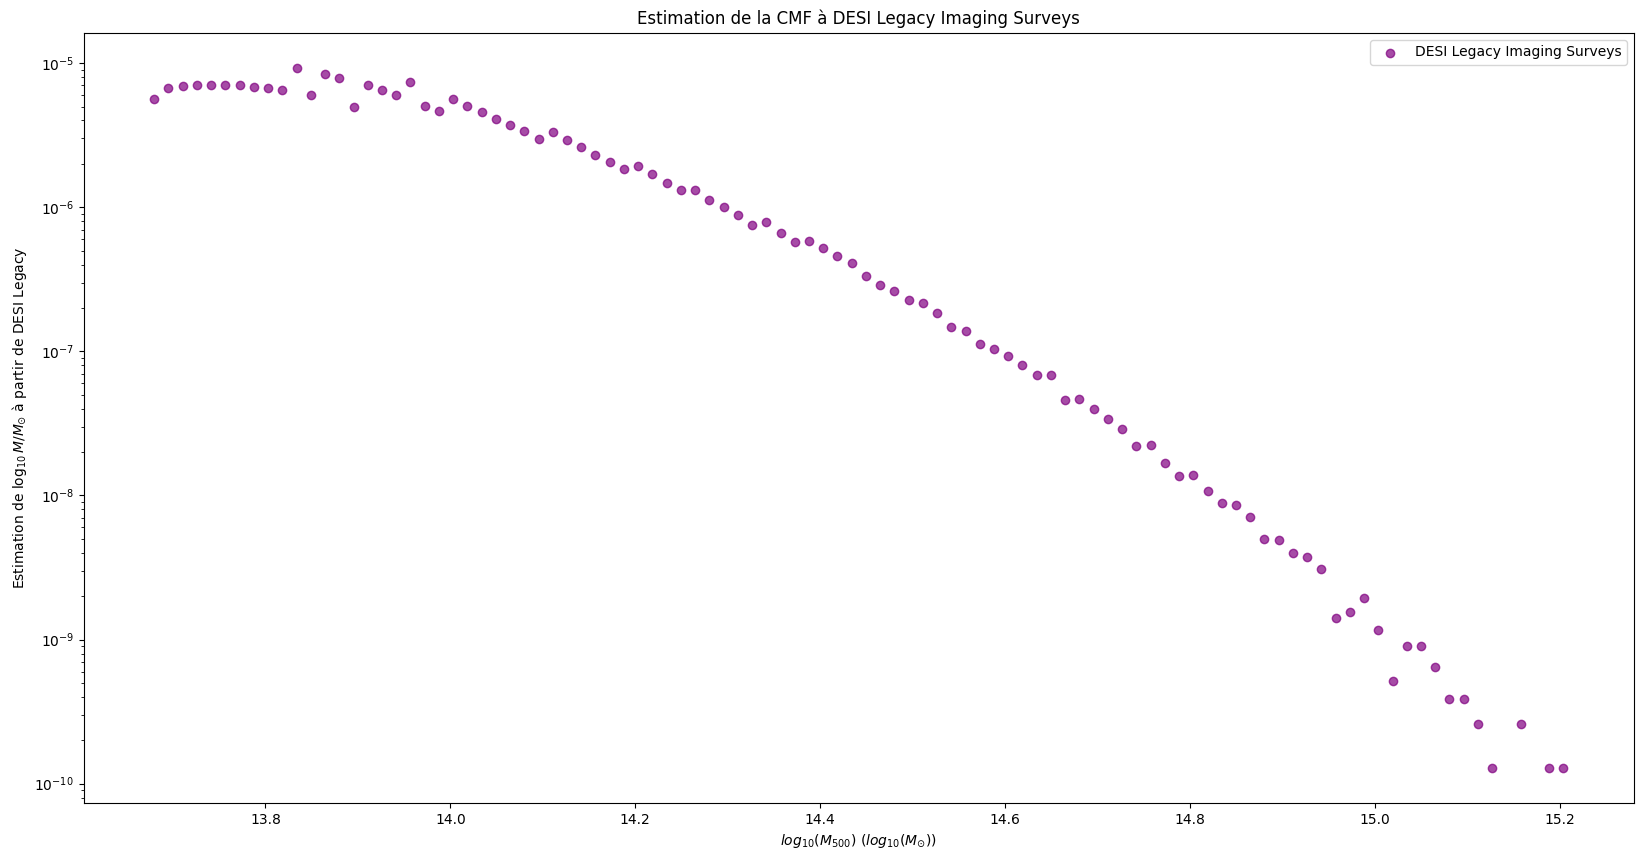

In [21]:
fig = plt.figure(figsize=(20, 10))
plt.scatter(bin_centers, n_DESI_Legacy, color='purple', label='DESI Legacy Imaging Surveys', alpha=0.7) 
plt.xlabel(r'$log_{10}(M_{500})$ ($log_{10}(M_{\odot})$)')
plt.ylabel(r'Estimation de $\log_{10} M / M_{\odot}$ à partir de DESI Legacy')
plt.yscale('log')
plt.title('Estimation de la CMF à DESI Legacy Imaging Surveys')
plt.legend()

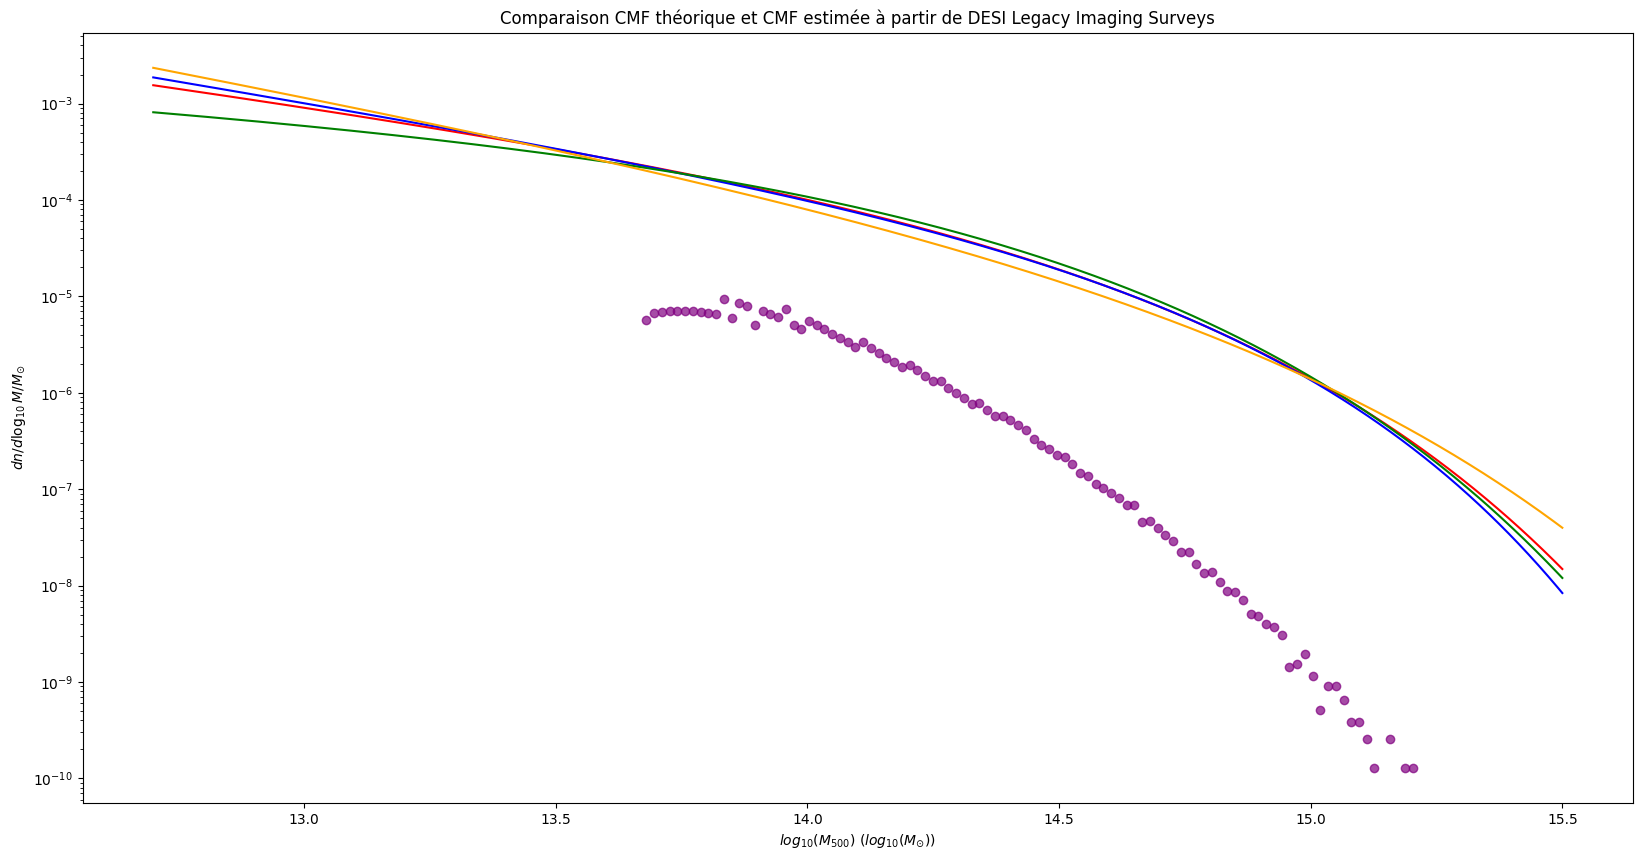

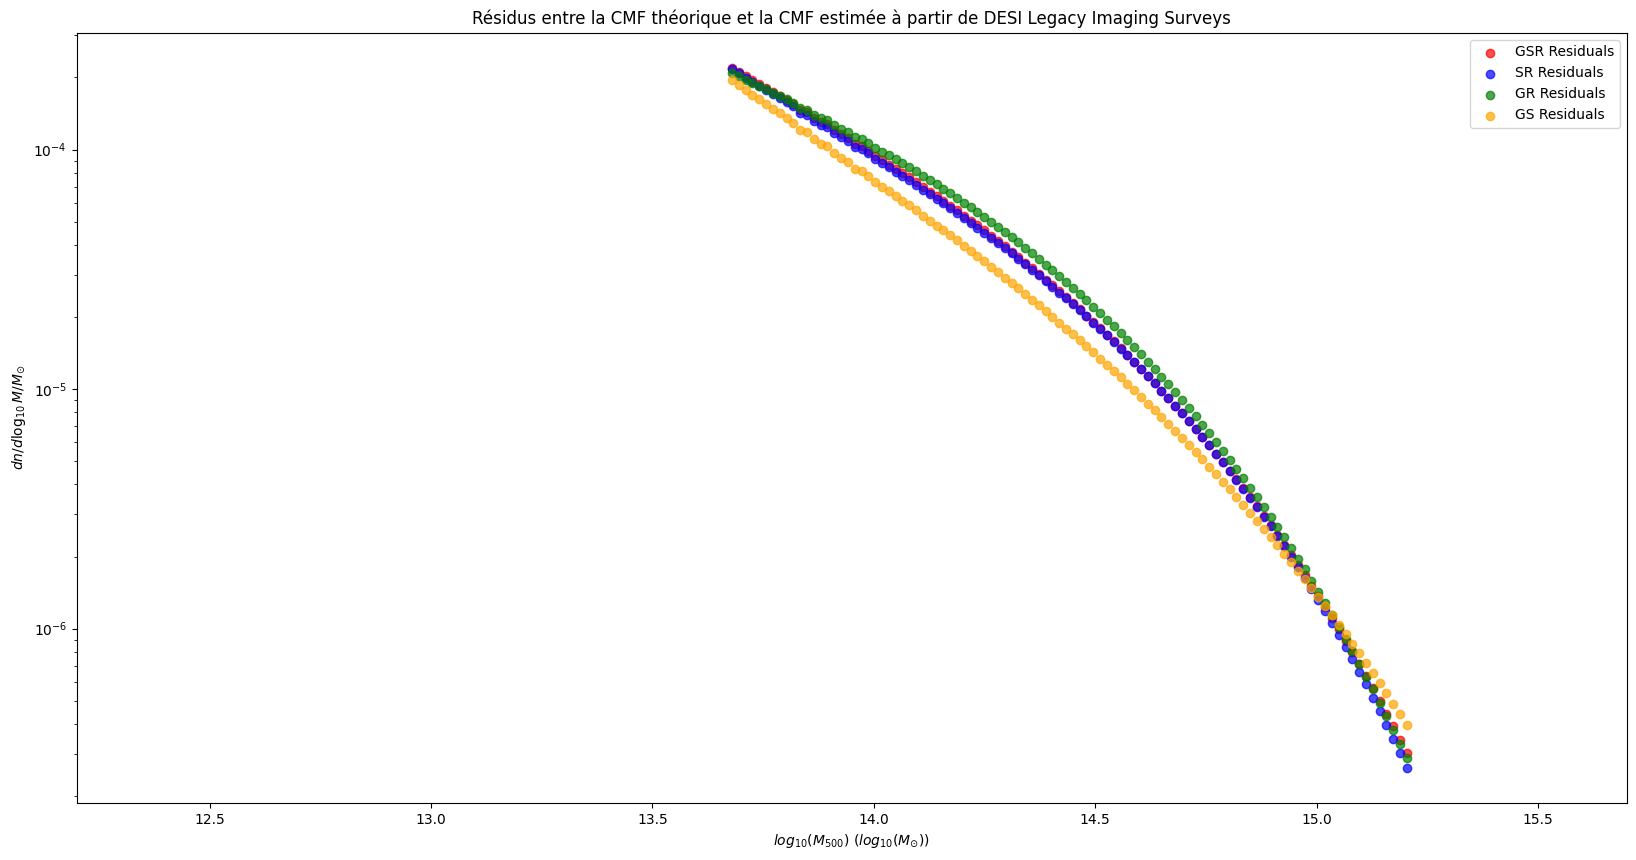

In [62]:
# Mpc ^-3 dex -1

# ATTENTION : On n'a pas pris en compte l'évolution en fonction du redshift, ni la masse de référence utilisée pour la fonction MRP (M500 ou autre chose ? → je n'arrive pas à trouver dans les papiers pour l'instant)

fig1 = plt.figure(figsize=(20, 10))

plt.plot(log10_M_Msun, CMF_GSR, label='GSR', color='red')
plt.plot(log10_M_Msun, CMF_SR, label='SR', color='blue')
plt.plot(log10_M_Msun, CMF_GR, label='GR', color='green')
plt.plot(log10_M_Msun, CMF_GS, label='GS', color='orange')

plt.scatter(bin_centers, n_DESI_Legacy, color='purple', label='DESI Legacy Imaging Surveys', alpha=0.7)

plt.xlabel(r'$log_{10}(M_{500})$ ($log_{10}(M_{\odot})$)')
plt.ylabel(r'$dn / d\log_{10} M / M_{\odot}$')
plt.yscale('log')
plt.title('Comparaison CMF théorique et CMF estimée à partir de DESI Legacy Imaging Surveys')


residuals_GSR = np.abs(CMF_GSR_func(bin_centers) - n_DESI_Legacy)
residuals_SR = np.abs(CMF_SR_func(bin_centers) - n_DESI_Legacy)
residuals_GR = np.abs(CMF_GR_func(bin_centers) - n_DESI_Legacy)
residuals_GS = np.abs(CMF_GS_func(bin_centers) - n_DESI_Legacy)


fig2 = plt.figure(figsize=(20, 10))
plt.scatter(bin_centers, residuals_GSR, color='red', label='GSR Residuals', alpha=0.7)
plt.scatter(bin_centers, residuals_SR, color='blue', label='SR Residuals', alpha=0.7)
plt.scatter(bin_centers, residuals_GR, color='green', label='GR Residuals', alpha=0.7)
plt.scatter(bin_centers, residuals_GS, color='orange', label='GS Residuals', alpha=0.7)
plt.xlim(12.2, 15.7)
plt.yscale('log')

plt.xlabel(r'$log_{10}(M_{500})$ ($log_{10}(M_{\odot})$)')
plt.ylabel(r'$dn / d\log_{10} M / M_{\odot}$')


plt.title('Résidus entre la CMF théorique et la CMF estimée à partir de DESI Legacy Imaging Surveys')

plt.legend()

In [59]:
type(n_DESI_Legacy)

numpy.ndarray

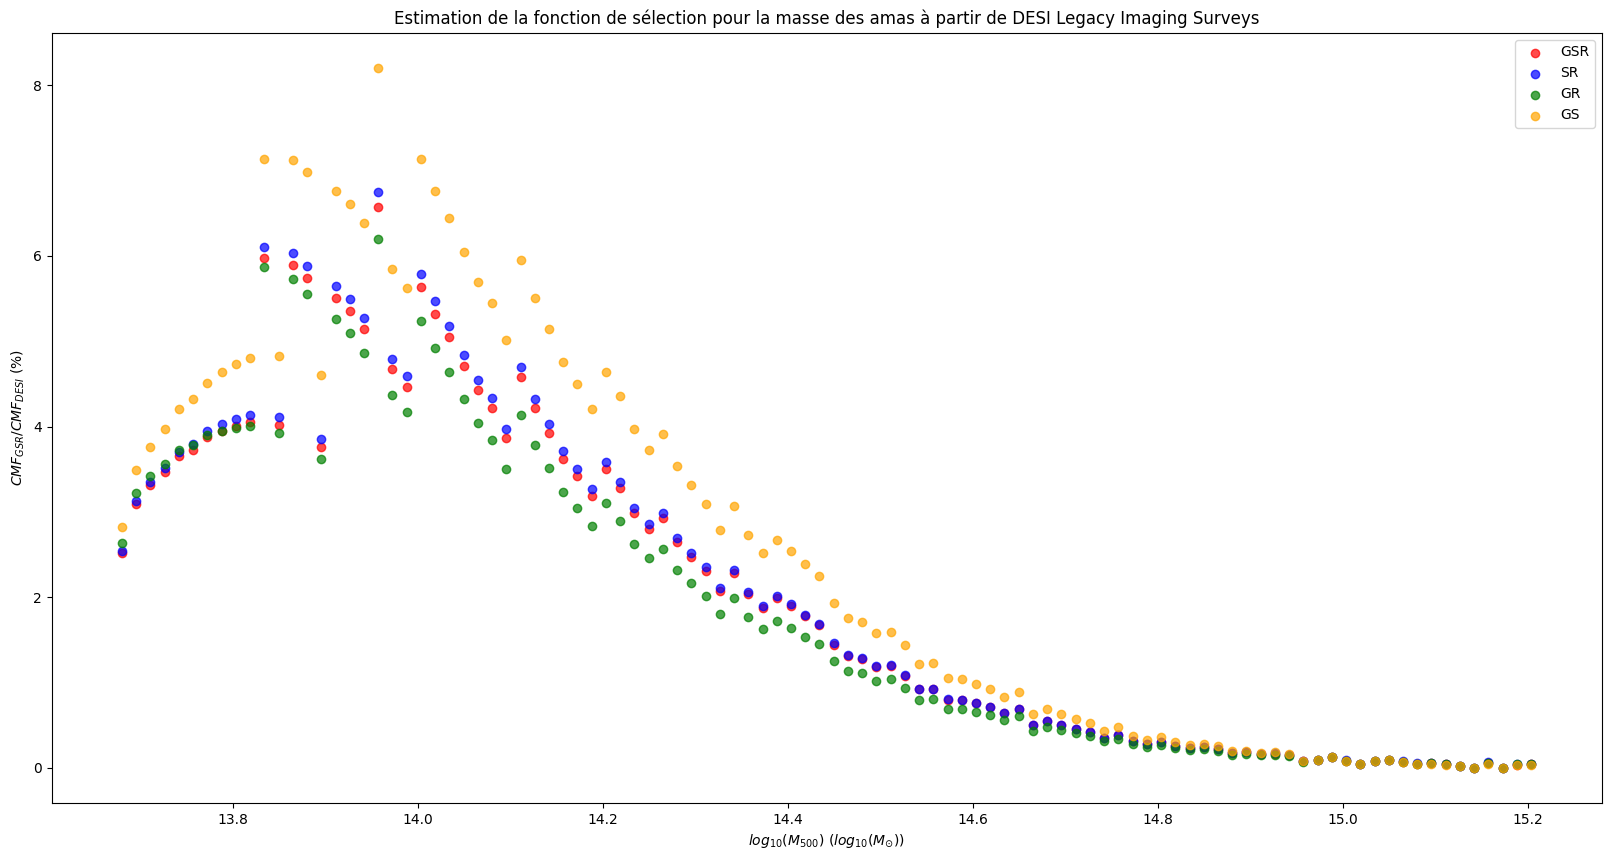

In [76]:
# On essaie d'en déduire une fonction de sélection en fonction de la masse des amas

estimation_selection_function_masse_GSR = n_DESI_Legacy/CMF_GSR_func(bin_centers)
estimation_selection_function_masse_SR = n_DESI_Legacy/CMF_SR_func(bin_centers)
estimation_selection_function_masse_GR = n_DESI_Legacy/CMF_GR_func(bin_centers)
estimation_selection_function_masse_GS = n_DESI_Legacy/CMF_GS_func(bin_centers)



plt.figure(figsize=(20, 10))

plt.scatter(bin_centers, estimation_selection_function_masse_GSR * 100, color='red', alpha=0.7,label='GSR')
plt.scatter(bin_centers, estimation_selection_function_masse_SR * 100, color='blue', alpha=0.7,label='SR')
plt.scatter(bin_centers, estimation_selection_function_masse_GR * 100, color='green', alpha=0.7,label='GR')
plt.scatter(bin_centers, estimation_selection_function_masse_GS * 100, color='orange', alpha=0.7,label='GS')


plt.xlabel(r'$log_{10}(M_{500})$ ($log_{10}(M_{\odot})$)')
plt.ylabel(r'$CMF_{GSR} / CMF_{DESI}$ (%)')
plt.title('Estimation de la fonction de sélection pour la masse des amas à partir de DESI Legacy Imaging Surveys')

plt.legend()

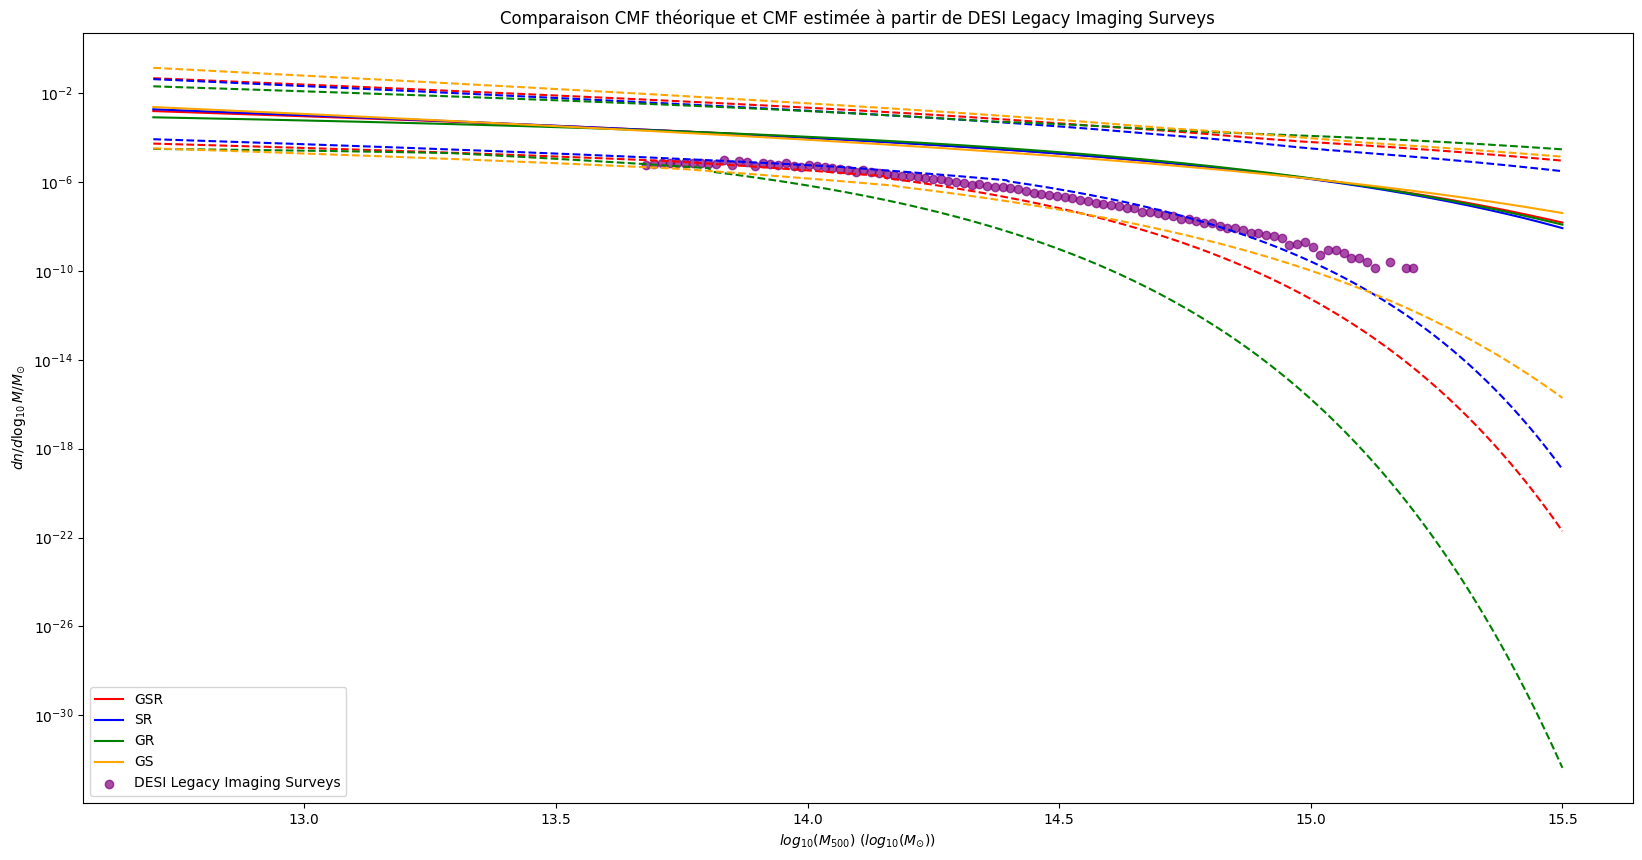

In [23]:
# Mpc ^-3 dex -1
fig = plt.figure(figsize=(20, 10))

plt.plot(log10_M_Msun, CMF_GSR, label='GSR', color='red')
plt.plot(log10_M_Msun, Borne_min_CMF_GSR, color='red',linestyle='dashed')
plt.plot(log10_M_Msun, Borne_max_CMF_GSR, color='red',linestyle='dashed')

plt.plot(log10_M_Msun, CMF_SR, label='SR', color='blue')
plt.plot(log10_M_Msun, Borne_min_CMF_SR, color='blue',linestyle='dashed')
plt.plot(log10_M_Msun, Borne_max_CMF_SR, color='blue',linestyle='dashed')

plt.plot(log10_M_Msun, CMF_GR, label='GR', color='green')
plt.plot(log10_M_Msun, Borne_min_CMF_GR, color='green',linestyle='dashed')
plt.plot(log10_M_Msun, Borne_max_CMF_GR, color='green',linestyle='dashed')

plt.plot(log10_M_Msun, CMF_GS, label='GS', color='orange')
plt.plot(log10_M_Msun, Borne_min_CMF_GS, color='orange',linestyle='dashed')
plt.plot(log10_M_Msun, Borne_max_CMF_GS, color='orange',linestyle='dashed')

plt.scatter(bin_centers, n_DESI_Legacy, color='purple', label='DESI Legacy Imaging Surveys', alpha=0.7)

plt.xlabel(r'$log_{10}(M_{500})$ ($log_{10}(M_{\odot})$)')
plt.ylabel(r'$dn / d\log_{10} M / M_{\odot}$')
plt.yscale('log')
plt.title('Comparaison CMF théorique et CMF estimée à partir de DESI Legacy Imaging Surveys')
plt.legend()

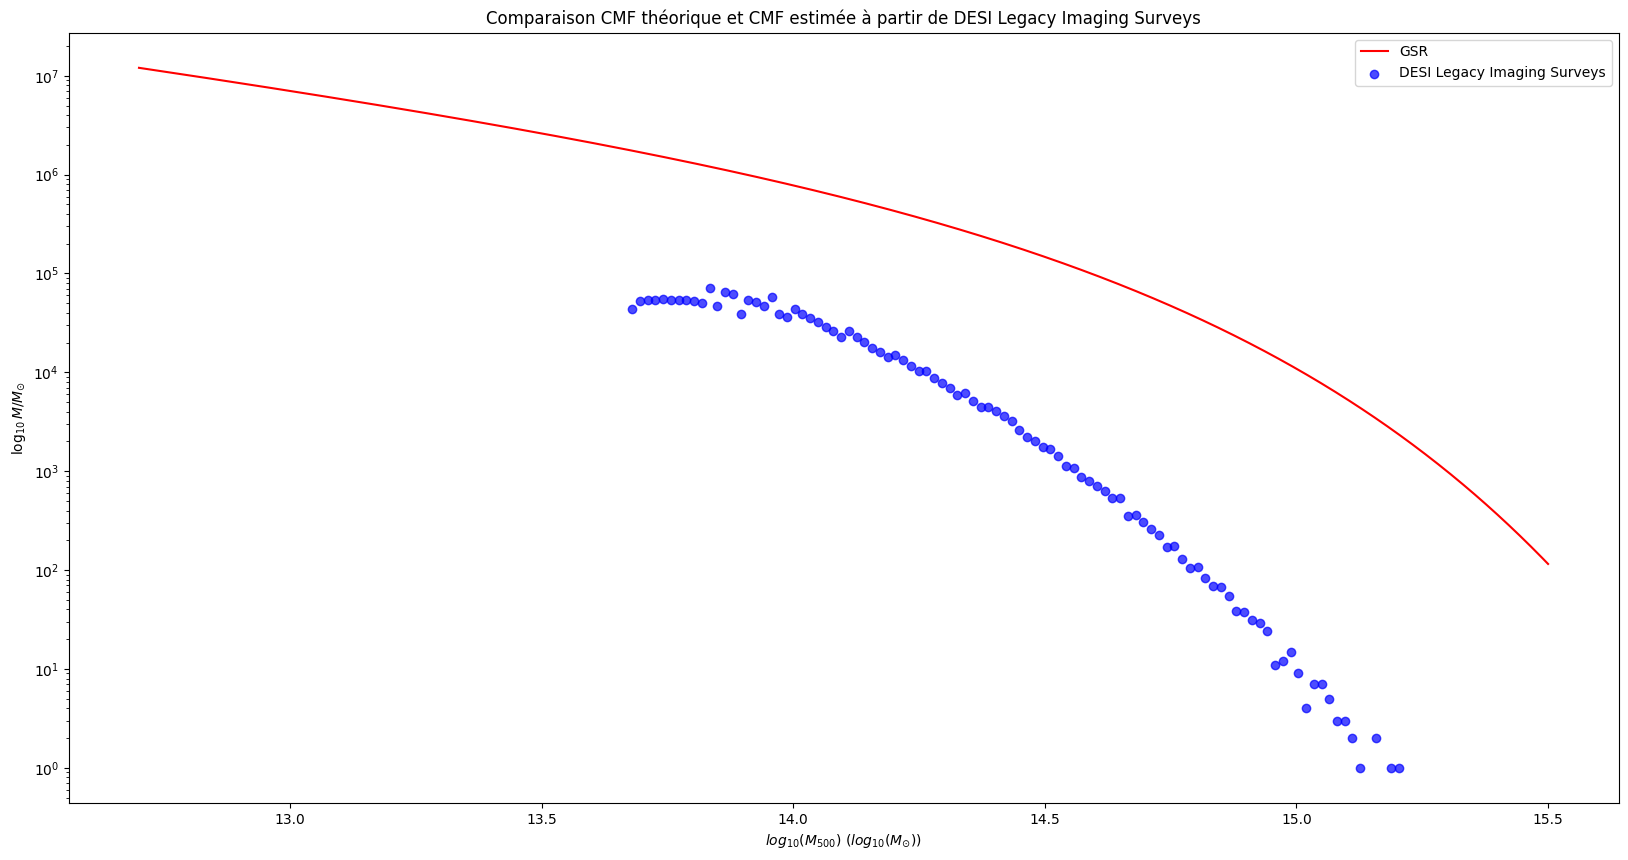

In [ ]:
# dex ^-1

fig = plt.figure(figsize=(20, 10))
plt.plot(log10_M_Msun, CMF_GSR*volume_DESI_LEGACY, label='GSR', color='red')
plt.scatter(bin_centers, counts, color='blue', label='DESI Legacy Imaging Surveys', alpha=0.7)
plt.xlabel(r'$log_{10}(M_{500})$ ($log_{10}(M_{\odot})$)')
plt.ylabel(r'$\log_{10} M / M_{\odot}$')
plt.yscale('log')
plt.title('Comparaison CMF théorique et CMF estimée à partir de DESI Legacy Imaging Surveys')
plt.legend()
